In [1]:
# 0,1: 00 for psi_1, 01 for psi_2 ...
# 2: For states
# 3,4: Ancillary qubits

# when theta = 32.56... 
# psi_1 = |0> 
# psi_2 = sqrt(2/3)|0> + sqrt(1/3)|1>
# psi_3 = sqrt(2/3)|0> - sqrt(1/3)|1>

In [2]:
from qiskit import QuantumCircuit
from numpy import sqrt
from qiskit.circuit.library import StatePreparation
def circuit_init():
    qc = QuantumCircuit(5)
    return qc

def PREP(qc):
    desired_vector = [sqrt(1/3), 0, sqrt(2)/3, 1/3, sqrt(2)/3, -1/3, 0, 0]
    prep = StatePreparation(desired_vector)
    qc.append(prep,[2,1,0])
    return qc

def CX01(qc, wires):
    qc.append(XGate().control(1, ctrl_state='1'),[wires[0], wires[1]])
    return qc

In [3]:
from qiskit.circuit.library.standard_gates import RYGate
from qiskit.circuit.library import UGate
from qiskit.circuit.library.standard_gates import XGate
from numpy import pi
 
def Ansatz(qc, wires, params):
    qc.u(params[0], params[1], params[2], wires[0])

    # set RYGate
    CRY1_1=RYGate(params[3],label='θ1_1').control(1,ctrl_state='0')
    CRY2_1=RYGate(params[4],label='θ2_1').control(1,ctrl_state='1')
    CRY1_2=RYGate(params[5],label='θ1_2').control(2,ctrl_state='10')
    CRY2_2=RYGate(params[6],label='θ2_2').control(2)

    # set VGate
    V1_1 = UGate(params[7],params[8],params[9],label = 'V1_1').control(1,ctrl_state='0')
    V2_1 = UGate(params[10],params[11],params[12],label = 'V2_1').control(1,ctrl_state='1')
    V1_2 = UGate(params[13],params[14],params[15],label = 'V1_2').control(2,ctrl_state='10')
    V2_2 = UGate(params[16],params[17],params[18],label = 'V2_2').control(2)

    # module 1
    qc.append(CRY1_1, [wires[0], wires[1]])
    qc.append(CRY2_1, [wires[0], wires[1]])
    qc.append(V1_1, [wires[1], wires[0]])
    qc.append(V2_1, [wires[1], wires[0]])
    #qc.cx(wires[2], wires[1])
    qc.append(CRY1_2, [wires[0], wires[1], wires[2]])
    qc.append(CRY2_2, [wires[0], wires[1], wires[2]])
    qc.append(V1_2, [wires[2], wires[1], wires[0]])
    qc.append(V2_2, [wires[2], wires[1], wires[0]])

    CX01(qc, [wires[2],wires[1]])
    
    qc.measure_all()
    return qc

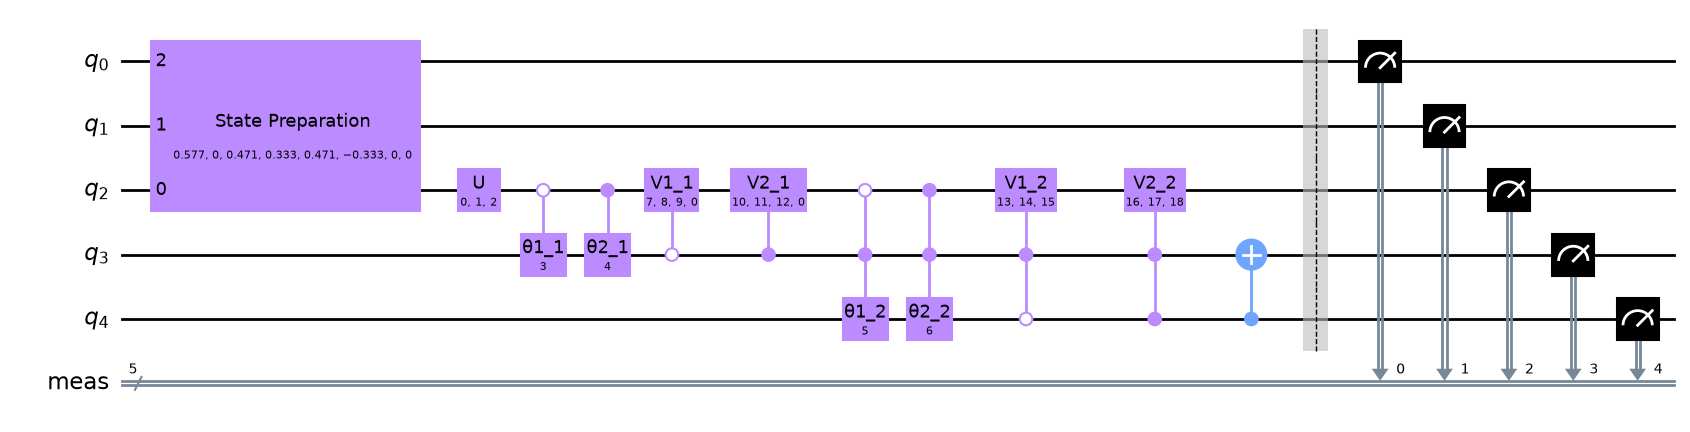

In [4]:
from numpy.random import rand

num_params= 19
params = list(range(num_params))

qc = circuit_init()
PREP(qc)
Ansatz(qc, [2,3,4] , params)

qc.draw(output='mpl', style = 'clifford') 
#qc_reversed=qc.reverse_bits()
#qc_reversed.draw(output='mpl',style = 'clifford') 

In [5]:
# ============================================================
# AWS Braket / IQM Garnet Setup
# ============================================================

from braket.aws import AwsDevice
from qiskit_braket_provider import BraketProvider
from qiskit import transpile
import numpy as np


GARNET_ARN = "arn:aws:braket:eu-north-1::device/qpu/iqm/Garnet"


# ============================================================
# Check IQM Garnet
# ============================================================

garnet_device = AwsDevice(
    GARNET_ARN
)

print(
    "Device name   :",
    garnet_device.name
)

print(
    "Device status :",
    garnet_device.status
)


try:

    qd = garnet_device.queue_depth()

    print(
        "Quantum-task queue :",
        qd.quantum_tasks
    )

    print(
        "Hybrid-job queue   :",
        qd.jobs
    )


except Exception as exc:

    print(
        "Queue depth unavailable:",
        exc
    )


# ============================================================
# Qiskit-Braket Backend
# ============================================================

provider = BraketProvider()

garnet_backend = provider.get_backend(
    "Garnet"
)

print(
    "Qiskit-Braket backend:",
    garnet_backend
)


# ============================================================
# Hardware Safety Switch
# ============================================================

HARDWARE_RUN = True


# ============================================================
# IQM Garnet Circuit Resource Report
# ============================================================

def circuit_resource_report(
    qc,
    backend,
    optimization_level=3,
    seed_transpiler=150
):

    tqc = transpile(
        qc,
        backend=backend,
        optimization_level=optimization_level,
        seed_transpiler=seed_transpiler
    )


    op_counts = dict(
        tqc.count_ops()
    )


    one_q = 0
    two_q = 0
    multi_q = 0
    measurements = 0


    for item in tqc.data:

        name = item.operation.name

        nq = len(
            item.qubits
        )


        if name == "measure":

            measurements += 1

        elif nq == 1:

            one_q += 1

        elif nq == 2:

            two_q += 1

        elif nq > 2:

            multi_q += 1


    metrics = {

        "num_qubits":
            tqc.num_qubits,

        "depth":
            tqc.depth(),

        "size":
            tqc.size(),

        "1q_gate_count":
            one_q,

        "2q_gate_count":
            two_q,

        "multiq_gate_count":
            multi_q,

        "measurement_count":
            measurements,

        "cz_count":
            int(
                op_counts.get(
                    "cz",
                    0
                )
            ),

        "cx_count":
            int(
                op_counts.get(
                    "cx",
                    0
                )
            ),

        "operation_counts":
            op_counts,
    }


    print(
        "\n=== IQM Garnet Transpiled Resource Report ==="
    )


    for key, value in metrics.items():

        print(
            f"{key:22s}: {value}"
        )


    return tqc, metrics

Device name   : Garnet
Device status : ONLINE
Quantum-task queue : {<QueueType.NORMAL: 'Normal'>: '0', <QueueType.PRIORITY: 'Priority'>: '0'}
Hybrid-job queue   : 0
Qiskit-Braket backend: BraketBackend[Garnet]


In [6]:
# ============================================================
# Representative Circuit Resource Check
# ============================================================
# This does NOT submit a QPU task.
#
# Random parameters are used so that transpilation does not
# artificially remove gates because of zero rotation angles.
#
# A fixed seed is used for reproducibility.
# ============================================================
import time
from scipy.optimize import minimize

RESOURCE_SEED = 150

resource_rng = np.random.default_rng(
    RESOURCE_SEED
)


resource_params = resource_rng.uniform(
    0.0,
    2.0 * np.pi,
    size=19
)


print(
    "\nResource-check random parameters:"
)

print(
    resource_params
)


qc_resource = circuit_init()


PREP(
    qc_resource
)


Ansatz(
    qc_resource,
    [2, 3, 4],
    resource_params
)


qc_resource = (
    qc_resource.reverse_bits()
)


garnet_transpiled_example, garnet_resource_metrics = (
    circuit_resource_report(

        qc_resource,

        garnet_backend,

        optimization_level=3,

        seed_transpiler=RESOURCE_SEED
    )
)


Resource-check random parameters:
[0.0302978  5.84830731 4.92967542 2.10062567 4.31195478 4.60094136
 5.18141143 0.67515615 1.94145203 1.96628163 3.73266894 3.8362028
 5.75880355 4.64212521 2.37171899 4.99483901 3.05950587 3.63728199
 6.1228061 ]

=== IQM Garnet Transpiled Resource Report ===
num_qubits            : 20
depth                 : 251
size                  : 394
1q_gate_count         : 298
2q_gate_count         : 91
multiq_gate_count     : 1
measurement_count     : 5
cz_count              : 91
cx_count              : 0
operation_counts      : {'r': 298, 'cz': 91, 'measure': 5, 'barrier': 1}


In [7]:
# ============================================================
# Settings
# ============================================================

num_times = 3

num_shots = 1000


optimizer_name = "COBYLA"

tol_value = 0.01

maxiter = 150


BASE_SEED = 150


report_filename = (
    "Sym_Naimark_IQM_Garnet_report.txt"
)


# ============================================================
# High-Shot Evaluation Settings
# ============================================================

evaluation_num_times = 5

evaluation_num_shots = 5000


EVALUATION_BASE_SEED = 10000


evaluation_seeds = np.array(
    [
        EVALUATION_BASE_SEED + i
        for i in range(
            evaluation_num_times
        )
    ],
    dtype=int
)


# ============================================================
# Storage
# ============================================================

final_optimized_values = []

initial_params_all_runs = []
optimal_params_all_runs = []


optimization_success_all_runs = []
optimization_status_all_runs = []
optimization_message_all_runs = []

optimization_nfev_all_runs = []

reached_maxiter_all_runs = []


# ============================================================
# Runtime Storage
# ============================================================

optimization_wall_times = []


# ============================================================
# IQM Garnet QPU Usage Storage
# ============================================================

garnet_task_count = 0

garnet_total_shots = 0

garnet_task_ids = []


# ============================================================
# High-Shot Evaluation Storage
# ============================================================

evaluation_values_all_runs = []

evaluation_mean_all_runs = []
evaluation_std_all_runs = []

evaluation_min_all_runs = []
evaluation_max_all_runs = []

# ============================================================
# Objective Function
# ============================================================

def objective_function(
    params,
    run_seed,
    shots=None,
    print_result=True
):

    global garnet_task_count
    global garnet_total_shots
    global garnet_task_ids


    if shots is None:

        shots = num_shots


    # ========================================================
    # Construct Circuit
    # ========================================================

    qc = circuit_init()


    PREP(
        qc
    )


    Ansatz(
        qc,
        [2, 3, 4],
        params
    )


    qc_reverse = (
        qc.reverse_bits()
    )


    # ========================================================
    # Transpile for IQM Garnet
    # ========================================================

    t_qc = transpile(
        qc_reverse,
        backend=garnet_backend,
        optimization_level=3,
        seed_transpiler=run_seed
    )


    # ========================================================
    # Hardware Safety Check
    # ========================================================

    if not HARDWARE_RUN:

        raise RuntimeError(
            "HARDWARE_RUN is False. "
            "QPU submission has been disabled."
        )


    # ========================================================
    # Submit to IQM Garnet
    # ========================================================

    job = garnet_backend.run(
        t_qc,
        shots=shots,
        verbatim=True
    )


    # ========================================================
    # Garnet Usage Accounting
    # ========================================================

    garnet_task_count += 1

    garnet_total_shots += int(
        shots
    )


    try:

        task_id = job.job_id()

        garnet_task_ids.append(
            task_id
        )


        if print_result:

            print(
                "Braket task ID:",
                task_id
            )


    except Exception:

        pass


    # ========================================================
    # Get Result
    # ========================================================

    result = job.result()

    counts = result.get_counts()


    # ========================================================
    # Target Counts
    # ========================================================
    #
    # Keep the original Sym Naimark bit indexing.
    # ========================================================

    tar_00 = 0

    tar_01 = 0

    tar_10 = 0


    for outcome, count in counts.items():


        if outcome[0:2] == "00":

            if outcome[3:5] == "00":

                tar_00 += count


        if outcome[0:2] == "01":

            if outcome[3:5] == "01":

                tar_01 += count


        if outcome[0:2] == "10":

            if outcome[3:5] == "10":

                tar_10 += count


    # ========================================================
    # Success Probability
    # ========================================================

    p_suc = (
        tar_00
        + tar_01
        + tar_10
    ) / shots


    if print_result:

        print(
            f"success_probability = "
            f"{p_suc:.8f}"
        )


    # ========================================================
    # Avoid Division by Zero
    # ========================================================

    if p_suc == 0:

        return 1e10


    # ========================================================
    # COBYLA minimizes.
    #
    # Therefore minimize:
    #
    #       1 / p_suc
    #
    # to maximize p_suc.
    # ========================================================

    return 1.0 / p_suc

In [8]:
# ============================================================
# Optimization + High-Shot Evaluation + Statistics + Report
# ============================================================

total_start_time = time.time()


# ============================================================
# Optimization
# ============================================================

for run in range(
    num_times
):

    print(
        "\n"
        + "=" * 100
    )

    print(
        f"Optimization Run "
        f"{run + 1}/{num_times}"
    )

    print(
        "=" * 100
    )


    # ========================================================
    # Seed for This Run
    # ========================================================

    run_seed = (
        BASE_SEED + run
    )


    rng = np.random.default_rng(
        run_seed
    )


    # ========================================================
    # Initial Parameters
    # ========================================================

    initial_params = rng.uniform(
        0.0,
        2.0 * np.pi,
        size=19
    )


    initial_params_all_runs.append(
        initial_params.copy()
    )


    print(
        f"\nOptimization Seed = "
        f"{run_seed}"
    )


    print(
        "\nInitial Parameters:"
    )

    print(
        initial_params
    )


    # ========================================================
    # Optimization
    # ========================================================

    optimization_start_time = (
        time.time()
    )


    result = minimize(

        fun=lambda params: objective_function(
            params,
            run_seed,
            shots=num_shots,
            print_result=True
        ),

        x0=initial_params,

        method=optimizer_name,

        options={
            "maxiter": maxiter,
            "disp": True,
            "tol": tol_value
        }
    )


    optimization_end_time = (
        time.time()
    )


    optimization_wall_time = (
        optimization_end_time
        - optimization_start_time
    )


    optimization_wall_times.append(
        optimization_wall_time
    )


    # ========================================================
    # Save Optimization Information
    # ========================================================

    optimal_params = (
        result.x.copy()
    )


    optimal_params_all_runs.append(
        optimal_params
    )


    optimization_success_all_runs.append(
        result.success
    )


    optimization_status_all_runs.append(
        result.status
    )


    optimization_message_all_runs.append(
        str(result.message)
    )


    optimization_nfev_all_runs.append(
        result.nfev
    )


    reached_maxiter = (
        result.nfev >= maxiter
    )


    reached_maxiter_all_runs.append(
        reached_maxiter
    )


    # ========================================================
    # Optimized Value
    # ========================================================

    if result.fun >= 1e10:

        optimized_value = 0.0

    else:

        optimized_value = (
            1.0 / result.fun
        )


    final_optimized_values.append(
        optimized_value
    )


    print(
        "\nOptimized Parameters:"
    )

    print(
        optimal_params
    )


    print(
        f"\nOptimized Value = "
        f"{optimized_value:.8f}"
    )


    print(
        f"Function Evaluations = "
        f"{result.nfev}"
    )


    print(
        f"Optimization Time = "
        f"{optimization_wall_time:.3f} s"
    )


    # ========================================================
    # High-Shot Evaluation
    # ========================================================

    print(
        "\n"
        + "-" * 100
    )

    print(
        "High-Shot Evaluation"
    )

    print(
        "-" * 100
    )


    evaluation_values = []


    for eval_index in range(
        evaluation_num_times
    ):

        eval_seed = (
            EVALUATION_BASE_SEED
            + run * evaluation_num_times
            + eval_index
        )


        eval_objective = objective_function(

            optimal_params,

            eval_seed,

            shots=evaluation_num_shots,

            print_result=False
        )


        if eval_objective >= 1e10:

            eval_value = 0.0

        else:

            eval_value = (
                1.0 / eval_objective
            )


        evaluation_values.append(
            eval_value
        )


        print(
            f"Evaluation "
            f"{eval_index + 1:2d}/"
            f"{evaluation_num_times:2d}"
            f" | Shots = "
            f"{evaluation_num_shots}"
            f" | Value = "
            f"{eval_value:.8f}"
        )


    evaluation_values = np.array(
        evaluation_values
    )


    evaluation_values_all_runs.append(
        evaluation_values.copy()
    )


    evaluation_mean = np.mean(
        evaluation_values
    )


    evaluation_std = np.std(
        evaluation_values
    )


    evaluation_min = np.min(
        evaluation_values
    )


    evaluation_max = np.max(
        evaluation_values
    )


    evaluation_mean_all_runs.append(
        evaluation_mean
    )


    evaluation_std_all_runs.append(
        evaluation_std
    )


    evaluation_min_all_runs.append(
        evaluation_min
    )


    evaluation_max_all_runs.append(
        evaluation_max
    )


    print(
        "\nEvaluation Summary:"
    )


    print(
        f"Mean = "
        f"{evaluation_mean:.8f}"
    )


    print(
        f"Std  = "
        f"{evaluation_std:.8f}"
    )


    print(
        f"Min  = "
        f"{evaluation_min:.8f}"
    )


    print(
        f"Max  = "
        f"{evaluation_max:.8f}"
    )


# ============================================================
# Total Runtime
# ============================================================

total_end_time = time.time()

total_wall_time = (
    total_end_time
    - total_start_time
)


# ============================================================
# Convert to Arrays
# ============================================================

final_optimized_values = np.array(
    final_optimized_values
)


evaluation_mean_all_runs = np.array(
    evaluation_mean_all_runs
)


evaluation_std_all_runs = np.array(
    evaluation_std_all_runs
)


evaluation_min_all_runs = np.array(
    evaluation_min_all_runs
)


evaluation_max_all_runs = np.array(
    evaluation_max_all_runs
)


optimization_nfev_all_runs = np.array(
    optimization_nfev_all_runs
)


optimization_wall_times = np.array(
    optimization_wall_times
)


# ============================================================
# Original Optimization-Shot Statistics
# ============================================================

max_optimized_value = np.max(
    final_optimized_values
)


max_optimized_run = np.argmax(
    final_optimized_values
)


mean_optimized_value = np.mean(
    final_optimized_values
)


std_optimized_value = np.std(
    final_optimized_values
)


# ============================================================
# High-Shot Evaluation Statistics
# ============================================================

best_evaluated_mean = np.max(
    evaluation_mean_all_runs
)


best_evaluated_run = np.argmax(
    evaluation_mean_all_runs
)


mean_of_evaluated_means = np.mean(
    evaluation_mean_all_runs
)


std_of_evaluated_means = np.std(
    evaluation_mean_all_runs
)


# ============================================================
# Optimizer Statistics
# ============================================================

mean_nfev = np.mean(
    optimization_nfev_all_runs
)


std_nfeval = np.std(
    optimization_nfev_all_runs
)


num_successful_runs = np.sum(
    optimization_success_all_runs
)


num_failed_runs = (
    num_times
    - num_successful_runs
)


num_reached_maxiter = np.sum(
    reached_maxiter_all_runs
)


# ============================================================
# Runtime Statistics
# ============================================================

total_optimization_time = np.sum(
    optimization_wall_times
)


mean_optimization_time = np.mean(
    optimization_wall_times
)


std_optimization_time = np.std(
    optimization_wall_times
)


# ============================================================
# PRINT SETTINGS
# ============================================================

print(
    "\n"
    + "=" * 100
)

print(
    "SETTINGS"
)

print(
    "=" * 100
)


print(
    f"Hardware                : IQM Garnet"
)

print(
    f"Hardware ARN            : {GARNET_ARN}"
)

print(
    f"Number of Runs          : {num_times}"
)

print(
    f"Optimization Shots      : {num_shots}"
)

print(
    f"Optimizer               : {optimizer_name}"
)

print(
    f"Tolerance               : {tol_value}"
)

print(
    f"Maximum Iterations      : {maxiter}"
)

print(
    f"Base Seed               : {BASE_SEED}"
)

print(
    f"Evaluation Repetitions  : {evaluation_num_times}"
)

print(
    f"Evaluation Shots        : {evaluation_num_shots}"
)

print(
    f"Evaluation Base Seed    : {EVALUATION_BASE_SEED}"
)

print(
    f"Resource Parameter Seed : {RESOURCE_SEED}"
)


# ============================================================
# INDIVIDUAL RUN RESULTS
# ============================================================

for run in range(
    num_times
):

    print(
        "\n"
        + "=" * 100
    )

    print(
        f"RUN {run + 1}"
    )

    print(
        "=" * 100
    )


    print(
        f"Optimization Seed : "
        f"{BASE_SEED + run}"
    )


    print(
        f"Optimized Value   : "
        f"{final_optimized_values[run]:.8f}"
    )


    print(
        f"Evaluated Mean    : "
        f"{evaluation_mean_all_runs[run]:.8f}"
    )


    print(
        f"Evaluated Std     : "
        f"{evaluation_std_all_runs[run]:.8f}"
    )


    print(
        f"Evaluated Min     : "
        f"{evaluation_min_all_runs[run]:.8f}"
    )


    print(
        f"Evaluated Max     : "
        f"{evaluation_max_all_runs[run]:.8f}"
    )


    print(
        f"Success           : "
        f"{optimization_success_all_runs[run]}"
    )


    print(
        f"Reached MaxIter   : "
        f"{reached_maxiter_all_runs[run]}"
    )


    print(
        f"Status            : "
        f"{optimization_status_all_runs[run]}"
    )


    print(
        f"Message           : "
        f"{optimization_message_all_runs[run]}"
    )


    print(
        f"Function Evals    : "
        f"{optimization_nfev_all_runs[run]}"
    )


    print(
        f"Optimization Time : "
        f"{optimization_wall_times[run]:.3f} s"
    )


    print(
        "\nEvaluated Values:"
    )

    print(
        evaluation_values_all_runs[run]
    )


    print(
        "\nInitial Parameters:"
    )

    print(
        initial_params_all_runs[run]
    )


    print(
        "\nOptimal Parameters:"
    )

    print(
        optimal_params_all_runs[run]
    )


# ============================================================
# SUMMARY
# ============================================================

print(
    "\n"
    + "=" * 100
)

print(
    "SUMMARY"
)

print(
    "=" * 100
)


print(
    "\nOriginal Optimization-Shot Results:"
)

print(
    f"Maximum Optimized Value : "
    f"{max_optimized_value:.8f}"
)

print(
    f"Maximum Run             : "
    f"{max_optimized_run + 1}"
)

print(
    f"Mean Optimized Value    : "
    f"{mean_optimized_value:.8f}"
)

print(
    f"Std Optimized Value     : "
    f"{std_optimized_value:.8f}"
)


print(
    "\nHigh-Shot Evaluation Results:"
)

print(
    f"Best Evaluated Mean     : "
    f"{best_evaluated_mean:.8f}"
)

print(
    f"Best Evaluated Mean Run : "
    f"{best_evaluated_run + 1}"
)

print(
    f"Mean of Evaluated Means : "
    f"{mean_of_evaluated_means:.8f}"
)

print(
    f"Std of Evaluated Means  : "
    f"{std_of_evaluated_means:.8f}"
)


print(
    "\nOptimizer Statistics:"
)

print(
    f"Mean Function Evals     : "
    f"{mean_nfev:.3f}"
)

print(
    f"Std Function Evals      : "
    f"{std_nfeval:.3f}"
)

print(
    f"Successful Runs         : "
    f"{num_successful_runs}/{num_times}"
)

print(
    f"Failed Runs             : "
    f"{num_failed_runs}/{num_times}"
)

print(
    f"Reached MaxIter         : "
    f"{num_reached_maxiter}/{num_times}"
)


print(
    "\nComputational Runtime Statistics:"
)

print(
    f"Total Wall-Clock Time   : "
    f"{total_wall_time:.3f} s"
)

print(
    f"Total Optimization Time : "
    f"{total_optimization_time:.3f} s"
)

print(
    f"Mean Opt. Time per Run  : "
    f"{mean_optimization_time:.3f} s"
)

print(
    f"Std Opt. Time per Run   : "
    f"{std_optimization_time:.3f} s"
)


# ============================================================
# BEST RUN ACCORDING TO ORIGINAL OPTIMIZED VALUE
# ============================================================

print(
    "\n"
    + "=" * 100
)

print(
    "BEST RUN ACCORDING TO ORIGINAL OPTIMIZED VALUE"
)

print(
    "=" * 100
)


print(
    f"Run             : "
    f"{max_optimized_run + 1}"
)

print(
    f"Optimized Value : "
    f"{final_optimized_values[max_optimized_run]:.8f}"
)

print(
    f"Evaluated Mean  : "
    f"{evaluation_mean_all_runs[max_optimized_run]:.8f}"
)

print(
    f"Evaluated Std   : "
    f"{evaluation_std_all_runs[max_optimized_run]:.8f}"
)

print(
    f"Evaluated Min   : "
    f"{evaluation_min_all_runs[max_optimized_run]:.8f}"
)

print(
    f"Evaluated Max   : "
    f"{evaluation_max_all_runs[max_optimized_run]:.8f}"
)


print(
    "\nEvaluated Values:"
)

print(
    evaluation_values_all_runs[max_optimized_run]
)


print(
    "\nInitial Parameters:"
)

print(
    initial_params_all_runs[max_optimized_run]
)


print(
    "\nOptimal Parameters:"
)

print(
    optimal_params_all_runs[max_optimized_run]
)


# ============================================================
# BEST RUN ACCORDING TO HIGH-SHOT EVALUATED MEAN
# ============================================================

print(
    "\n"
    + "=" * 100
)

print(
    "BEST RUN ACCORDING TO HIGH-SHOT EVALUATED MEAN"
)

print(
    "=" * 100
)


print(
    f"Run             : "
    f"{best_evaluated_run + 1}"
)

print(
    f"Optimized Value : "
    f"{final_optimized_values[best_evaluated_run]:.8f}"
)

print(
    f"Evaluated Mean  : "
    f"{evaluation_mean_all_runs[best_evaluated_run]:.8f}"
)

print(
    f"Evaluated Std   : "
    f"{evaluation_std_all_runs[best_evaluated_run]:.8f}"
)

print(
    f"Evaluated Min   : "
    f"{evaluation_min_all_runs[best_evaluated_run]:.8f}"
)

print(
    f"Evaluated Max   : "
    f"{evaluation_max_all_runs[best_evaluated_run]:.8f}"
)


print(
    "\nEvaluated Values:"
)

print(
    evaluation_values_all_runs[best_evaluated_run]
)


print(
    "\nInitial Parameters:"
)

print(
    initial_params_all_runs[best_evaluated_run]
)


print(
    "\nOptimal Parameters:"
)

print(
    optimal_params_all_runs[best_evaluated_run]
)


# ============================================================
# IQM Garnet QPU Usage Summary
# ============================================================

print(
    "\n"
    + "=" * 100
)

print(
    "IQM GARNET QPU USAGE SUMMARY"
)

print(
    "=" * 100
)


print(
    f"Total QPU Tasks Submitted : "
    f"{garnet_task_count}"
)

print(
    f"Total QPU Shots Submitted : "
    f"{garnet_total_shots}"
)


print(
    "\nBraket Task IDs:"
)


for i, task_id in enumerate(
    garnet_task_ids,
    start=1
):

    print(
        f"{i:4d}: {task_id}"
    )


print(
    "\nRepresentative Transpiled Circuit Resources:"
)


for key, value in garnet_resource_metrics.items():

    print(
        f"{key:22s}: {value}"
    )


# ============================================================
# WRITE REPORT TO TXT FILE
# ============================================================

with open(
    report_filename,
    "w"
) as f:

    # ========================================================
    # SETTINGS
    # ========================================================

    f.write(
        "=" * 100
        + "\n"
    )

    f.write(
        "SETTINGS\n"
    )

    f.write(
        "=" * 100
        + "\n"
    )


    f.write(
        f"Hardware                : IQM Garnet\n"
    )

    f.write(
        f"Hardware ARN            : {GARNET_ARN}\n"
    )

    f.write(
        f"Number of Runs          : {num_times}\n"
    )

    f.write(
        f"Optimization Shots      : {num_shots}\n"
    )

    f.write(
        f"Optimizer               : {optimizer_name}\n"
    )

    f.write(
        f"Tolerance               : {tol_value}\n"
    )

    f.write(
        f"Maximum Iterations      : {maxiter}\n"
    )

    f.write(
        f"Base Seed               : {BASE_SEED}\n"
    )

    f.write(
        f"Evaluation Repetitions  : {evaluation_num_times}\n"
    )

    f.write(
        f"Evaluation Shots        : {evaluation_num_shots}\n"
    )

    f.write(
        f"Evaluation Base Seed    : {EVALUATION_BASE_SEED}\n"
    )

    f.write(
        f"Resource Parameter Seed : {RESOURCE_SEED}\n"
    )


    # ========================================================
    # INDIVIDUAL RUN RESULTS
    # ========================================================

    for run in range(
        num_times
    ):

        f.write(
            "\n"
            + "=" * 100
            + "\n"
        )

        f.write(
            f"RUN {run + 1}\n"
        )

        f.write(
            "=" * 100
            + "\n"
        )


        f.write(
            f"Optimization Seed : "
            f"{BASE_SEED + run}\n"
        )

        f.write(
            f"Optimized Value   : "
            f"{final_optimized_values[run]:.8f}\n"
        )

        f.write(
            f"Evaluated Mean    : "
            f"{evaluation_mean_all_runs[run]:.8f}\n"
        )

        f.write(
            f"Evaluated Std     : "
            f"{evaluation_std_all_runs[run]:.8f}\n"
        )

        f.write(
            f"Evaluated Min     : "
            f"{evaluation_min_all_runs[run]:.8f}\n"
        )

        f.write(
            f"Evaluated Max     : "
            f"{evaluation_max_all_runs[run]:.8f}\n"
        )

        f.write(
            f"Success           : "
            f"{optimization_success_all_runs[run]}\n"
        )

        f.write(
            f"Reached MaxIter   : "
            f"{reached_maxiter_all_runs[run]}\n"
        )

        f.write(
            f"Status            : "
            f"{optimization_status_all_runs[run]}\n"
        )

        f.write(
            f"Message           : "
            f"{optimization_message_all_runs[run]}\n"
        )

        f.write(
            f"Function Evals    : "
            f"{optimization_nfev_all_runs[run]}\n"
        )

        f.write(
            f"Optimization Time : "
            f"{optimization_wall_times[run]:.3f} s\n"
        )


        f.write(
            "\nEvaluated Values:\n"
        )

        f.write(
            np.array2string(
                np.array(
                    evaluation_values_all_runs[run]
                ),
                precision=10,
                separator=", "
            )
            + "\n"
        )


        f.write(
            "\nInitial Parameters:\n"
        )

        f.write(
            np.array2string(
                np.array(
                    initial_params_all_runs[run]
                ),
                precision=10,
                separator=", "
            )
            + "\n"
        )


        f.write(
            "\nOptimal Parameters:\n"
        )

        f.write(
            np.array2string(
                np.array(
                    optimal_params_all_runs[run]
                ),
                precision=10,
                separator=", "
            )
            + "\n"
        )


    # ========================================================
    # SUMMARY
    # ========================================================

    f.write(
        "\n"
        + "=" * 100
        + "\n"
    )

    f.write(
        "SUMMARY\n"
    )

    f.write(
        "=" * 100
        + "\n"
    )


    f.write(
        "\nOriginal Optimization-Shot Results:\n"
    )

    f.write(
        f"Maximum Optimized Value : "
        f"{max_optimized_value:.8f}\n"
    )

    f.write(
        f"Maximum Run             : "
        f"{max_optimized_run + 1}\n"
    )

    f.write(
        f"Mean Optimized Value    : "
        f"{mean_optimized_value:.8f}\n"
    )

    f.write(
        f"Std Optimized Value     : "
        f"{std_optimized_value:.8f}\n"
    )


    f.write(
        "\nHigh-Shot Evaluation Results:\n"
    )

    f.write(
        f"Best Evaluated Mean     : "
        f"{best_evaluated_mean:.8f}\n"
    )

    f.write(
        f"Best Evaluated Mean Run : "
        f"{best_evaluated_run + 1}\n"
    )

    f.write(
        f"Mean of Evaluated Means : "
        f"{mean_of_evaluated_means:.8f}\n"
    )

    f.write(
        f"Std of Evaluated Means  : "
        f"{std_of_evaluated_means:.8f}\n"
    )


    f.write(
        "\nOptimizer Statistics:\n"
    )

    f.write(
        f"Mean Function Evals     : "
        f"{mean_nfev:.3f}\n"
    )

    f.write(
        f"Std Function Evals      : "
        f"{std_nfeval:.3f}\n"
    )

    f.write(
        f"Successful Runs         : "
        f"{num_successful_runs}/{num_times}\n"
    )

    f.write(
        f"Failed Runs             : "
        f"{num_failed_runs}/{num_times}\n"
    )

    f.write(
        f"Reached MaxIter         : "
        f"{num_reached_maxiter}/{num_times}\n"
    )


    f.write(
        "\nComputational Runtime Statistics:\n"
    )

    f.write(
        f"Total Wall-Clock Time   : "
        f"{total_wall_time:.3f} s\n"
    )

    f.write(
        f"Total Optimization Time : "
        f"{total_optimization_time:.3f} s\n"
    )

    f.write(
        f"Mean Opt. Time per Run  : "
        f"{mean_optimization_time:.3f} s\n"
    )

    f.write(
        f"Std Opt. Time per Run   : "
        f"{std_optimization_time:.3f} s\n"
    )


    # ========================================================
    # BEST RUN ACCORDING TO ORIGINAL OPTIMIZED VALUE
    # ========================================================

    f.write(
        "\n"
        + "=" * 100
        + "\n"
    )

    f.write(
        "BEST RUN ACCORDING TO ORIGINAL OPTIMIZED VALUE\n"
    )

    f.write(
        "=" * 100
        + "\n"
    )


    f.write(
        f"Run             : "
        f"{max_optimized_run + 1}\n"
    )

    f.write(
        f"Optimized Value : "
        f"{final_optimized_values[max_optimized_run]:.8f}\n"
    )

    f.write(
        f"Evaluated Mean  : "
        f"{evaluation_mean_all_runs[max_optimized_run]:.8f}\n"
    )

    f.write(
        f"Evaluated Std   : "
        f"{evaluation_std_all_runs[max_optimized_run]:.8f}\n"
    )

    f.write(
        f"Evaluated Min   : "
        f"{evaluation_min_all_runs[max_optimized_run]:.8f}\n"
    )

    f.write(
        f"Evaluated Max   : "
        f"{evaluation_max_all_runs[max_optimized_run]:.8f}\n"
    )


    f.write(
        "\nEvaluated Values:\n"
    )

    f.write(
        np.array2string(
            np.array(
                evaluation_values_all_runs[max_optimized_run]
            ),
            precision=10,
            separator=", "
        )
        + "\n"
    )


    f.write(
        "\nInitial Parameters:\n"
    )

    f.write(
        np.array2string(
            np.array(
                initial_params_all_runs[max_optimized_run]
            ),
            precision=10,
            separator=", "
        )
        + "\n"
    )


    f.write(
        "\nOptimal Parameters:\n"
    )

    f.write(
        np.array2string(
            np.array(
                optimal_params_all_runs[max_optimized_run]
            ),
            precision=10,
            separator=", "
        )
        + "\n"
    )


    # ========================================================
    # BEST RUN ACCORDING TO HIGH-SHOT EVALUATED MEAN
    # ========================================================

    f.write(
        "\n"
        + "=" * 100
        + "\n"
    )

    f.write(
        "BEST RUN ACCORDING TO HIGH-SHOT EVALUATED MEAN\n"
    )

    f.write(
        "=" * 100
        + "\n"
    )


    f.write(
        f"Run             : "
        f"{best_evaluated_run + 1}\n"
    )

    f.write(
        f"Optimized Value : "
        f"{final_optimized_values[best_evaluated_run]:.8f}\n"
    )

    f.write(
        f"Evaluated Mean  : "
        f"{evaluation_mean_all_runs[best_evaluated_run]:.8f}\n"
    )

    f.write(
        f"Evaluated Std   : "
        f"{evaluation_std_all_runs[best_evaluated_run]:.8f}\n"
    )

    f.write(
        f"Evaluated Min   : "
        f"{evaluation_min_all_runs[best_evaluated_run]:.8f}\n"
    )

    f.write(
        f"Evaluated Max   : "
        f"{evaluation_max_all_runs[best_evaluated_run]:.8f}\n"
    )


    f.write(
        "\nEvaluated Values:\n"
    )

    f.write(
        np.array2string(
            np.array(
                evaluation_values_all_runs[best_evaluated_run]
            ),
            precision=10,
            separator=", "
        )
        + "\n"
    )


    f.write(
        "\nInitial Parameters:\n"
    )

    f.write(
        np.array2string(
            np.array(
                initial_params_all_runs[best_evaluated_run]
            ),
            precision=10,
            separator=", "
        )
        + "\n"
    )


    f.write(
        "\nOptimal Parameters:\n"
    )

    f.write(
        np.array2string(
            np.array(
                optimal_params_all_runs[best_evaluated_run]
            ),
            precision=10,
            separator=", "
        )
        + "\n"
    )


    # ========================================================
    # IQM Garnet QPU Usage Summary
    # ========================================================

    f.write(
        "\n"
        + "=" * 100
        + "\n"
    )

    f.write(
        "IQM GARNET QPU USAGE SUMMARY\n"
    )

    f.write(
        "=" * 100
        + "\n"
    )


    f.write(
        f"Total QPU Tasks Submitted : "
        f"{garnet_task_count}\n"
    )

    f.write(
        f"Total QPU Shots Submitted : "
        f"{garnet_total_shots}\n"
    )


    f.write(
        "\nBraket Task IDs:\n"
    )


    for i, task_id in enumerate(
        garnet_task_ids,
        start=1
    ):

        f.write(
            f"{i:4d}: {task_id}\n"
        )


    f.write(
        "\nRepresentative Transpiled Circuit Resources:\n"
    )


    for key, value in garnet_resource_metrics.items():

        f.write(
            f"{key:22s}: {value}\n"
        )


print(
    f"\nReport saved to: "
    f"{report_filename}"
)


Optimization Run 1/3

Optimization Seed = 150

Initial Parameters:
[0.0302978  5.84830731 4.92967542 2.10062567 4.31195478 4.60094136
 5.18141143 0.67515615 1.94145203 1.96628163 3.73266894 3.8362028
 5.75880355 4.64212521 2.37171899 4.99483901 3.05950587 3.63728199
 6.1228061 ]


/Users/sungwonyun/anaconda3/lib/python3.11/site-packages/qiskit_braket_provider/providers/adapter.py:270: UserWarning: Barrier is not included in the current Target and will be ignored.
  _translate_to_braket(
/Users/sungwonyun/anaconda3/lib/python3.11/site-packages/qiskit_braket_provider/providers/adapter.py:270: UserWarning: Device does not support global phase; global phase of 3.8369236574233 will not be included in Braket circuit
  _translate_to_braket(


Braket task ID: arn:aws:braket:eu-north-1:082674088760:quantum-task/d2bab93e-5e58-4f47-a328-ca7921c39911
success_probability = 0.26800000


/Users/sungwonyun/anaconda3/lib/python3.11/site-packages/qiskit_braket_provider/providers/adapter.py:270: UserWarning: Device does not support global phase; global phase of 5.407719984218195 will not be included in Braket circuit
  _translate_to_braket(


Braket task ID: arn:aws:braket:eu-north-1:082674088760:quantum-task/ada07507-b711-4c83-997e-8a1ffeb1dd87
success_probability = 0.27700000


...

Evaluation  2/ 5 | Shots = 5000 | Value = 0.32280000


/Users/sungwonyun/anaconda3/lib/python3.11/site-packages/qiskit_braket_provider/providers/adapter.py:270: UserWarning: Device does not support global phase; global phase of 2.8431260942837344 will not be included in Braket circuit
  _translate_to_braket(


Evaluation  3/ 5 | Shots = 5000 | Value = 0.28160000
Evaluation  4/ 5 | Shots = 5000 | Value = 0.26140000


/Users/sungwonyun/anaconda3/lib/python3.11/site-packages/qiskit_braket_provider/providers/adapter.py:270: UserWarning: Device does not support global phase; global phase of 1.2723297674888556 will not be included in Braket circuit
  _translate_to_braket(


Evaluation  5/ 5 | Shots = 5000 | Value = 0.28140000

Evaluation Summary:
Mean = 0.28480000
Std  = 0.02038313
Min  = 0.26140000
Max  = 0.32280000

SETTINGS
Hardware                : IQM Garnet
Hardware ARN            : arn:aws:braket:eu-north-1::device/qpu/iqm/Garnet
Number of Runs          : 3
Optimization Shots      : 1000
Optimizer               : COBYLA
Tolerance               : 0.01
Maximum Iterations      : 150
Base Seed               : 150
Evaluation Repetitions  : 5
Evaluation Shots        : 5000
Evaluation Base Seed    : 10000
Resource Parameter Seed : 150

RUN 1
Optimization Seed : 150
Optimized Value   : 0.25900000
Evaluated Mean    : 0.27948000
Evaluated Std     : 0.01717421
Evaluated Min     : 0.25520000
Evaluated Max     : 0.30020000
Success           : True
Reached MaxIter   : False
Status            : 1
Message           : Optimization terminated successfully.
Function Evals    : 94
Optimization Time : 613.533 s

Evaluated Values:
[0.2634 0.3002 0.2878 0.2908 0.2552]

I